# Neural Network Analysis: Breast Cancer Classification
## DATA 5322 Final Project | Ruman Sidhu

**Research question:** Can supervised ML distinguish breast cancer tumour tissue from normal breast tissue using gene expression profiles alone - and do the unsupervised clusters from our PH4 analysis reflect this biological boundary?

**Model:** Multilayer Perceptron (MLP) Neural Network  
**Dataset:** BC-TCGA - 529 tumour samples · 61 normal samples · 17,814 gene expression features  
**Labels:** 1 = Tumour, 0 = Normal (derived from source file)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("All packages loaded.")

TensorFlow: 2.21.0
All packages loaded.


In [9]:
# The Color Palette
ELECTRIC_TEAL  = '#00DDB8'
CORAL_RED      = '#FF4D4D'
MIDNIGHT_NAVY  = '#0A1628'
DEEP_SURFACE   = '#0F2035'
STEEL_BLUE     = '#6A9AB0'
FOREST_TEAL    = '#006D5B'
OCEAN_TEAL     = '#1D6B61'
SKY_CYAN       = '#4BBFCC'
NAVY_ACCENT    = '#1E4A6B'
SLATE_BLUE     = '#1A4A7A'

## 1. Load Data

In [6]:
# Adjust paths to match local repo structure
TUMOR_PATH  = '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Final Project/BC-TCGA/BC-TCGA-Tumor.txt'
NORMAL_PATH = '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Final Project/BC-TCGA/BC-TCGA-Normal.txt'

# Load - genes are rows, samples are columns
tumor_df  = pd.read_csv(TUMOR_PATH,  sep='\t', index_col=0)
normal_df = pd.read_csv(NORMAL_PATH, sep='\t', index_col=0)

print(f"Tumour data:  {tumor_df.shape[1]} samples × {tumor_df.shape[0]} genes")
print(f"Normal data:  {normal_df.shape[1]} samples × {normal_df.shape[0]} genes")

Tumour data:  529 samples × 17814 genes
Normal data:  61 samples × 17814 genes


## 2. Create Labels and Combine

In [7]:
# Transpose: samples as rows, genes as columns
X_tumor  = tumor_df.T
X_normal = normal_df.T

y_tumor  = np.ones(X_tumor.shape[0])   # 1 = Tumour
y_normal = np.zeros(X_normal.shape[0]) # 0 = Normal

X = pd.concat([X_tumor, X_normal], axis=0).reset_index(drop=True)
y = np.concatenate([y_tumor, y_normal])

print(f"Combined dataset: {X.shape[0]} samples × {X.shape[1]} genes")
print(f"  Tumour: {int(y.sum())} samples ({y.mean()*100:.1f}%)")
print(f"  Normal: {int((1-y).sum())} samples ({(1-y).mean()*100:.1f}%)")
print(f"\nNote: class imbalance present — will use class_weight and weighted F1.")

Combined dataset: 590 samples × 17814 genes
  Tumour: 529 samples (89.7%)
  Normal: 61 samples (10.3%)

Note: class imbalance present — will use class_weight and weighted F1.


## 3. Preprocessing

In [8]:
# Step 1: Fill any missing values
X_clean = X.fillna(X.mean())

# Step 2: Remove near-zero variance genes
selector = VarianceThreshold(threshold=0.1)
X_filtered = selector.fit_transform(X_clean)
genes_kept = np.array(X_clean.columns)[selector.get_support()]
print(f"Genes after variance filtering: {X_filtered.shape[1]} (removed {X.shape[1] - X_filtered.shape[1]})")

# Step 3: Standardise (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
print(f"Standardisation done. Mean ≈ {X_scaled.mean():.4f}, Std ≈ {X_scaled.std():.4f}")

Genes after variance filtering: 17488 (removed 326)
Standardisation done. Mean ≈ -0.0000, Std ≈ 1.0000


## 4. Dimensionality Reduction (PCA)

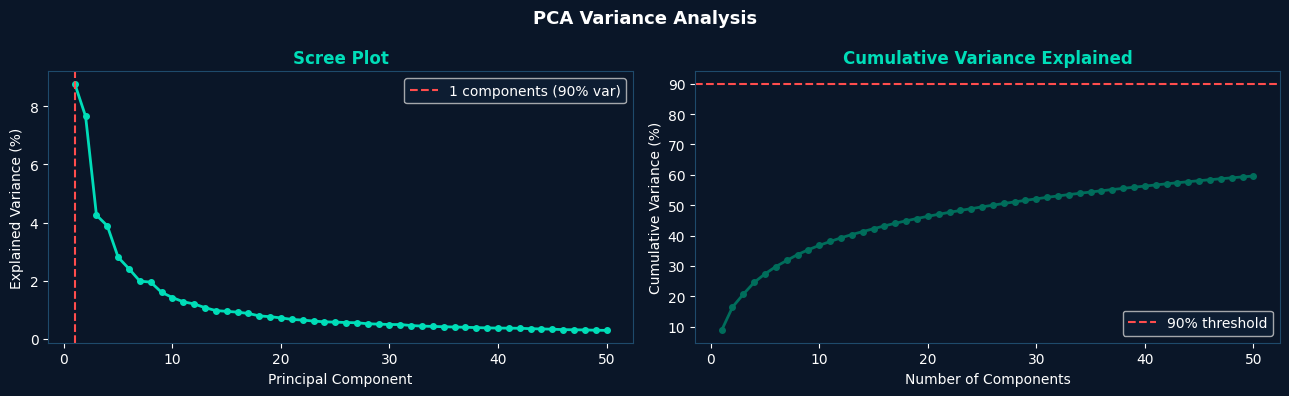


Components for 90% variance: 1
50 components explain: 59.6% of variance

Final feature matrix for modelling: (590, 1)
(Reduced from 17488 genes to 1 principal components)


In [10]:
# Fit PCA with 50 components first to inspect variance
pca_explore = PCA(n_components=50, random_state=42)
pca_explore.fit(X_scaled)
cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

# Find how many components explain 90% of variance
n_90 = int(np.argmax(cumvar >= 0.90)) + 1

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0A1628')

for ax in axes:
    ax.set_facecolor('#0A1628')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#1E4A6B')

axes[0].plot(range(1, 51), pca_explore.explained_variance_ratio_ * 100,
             'o-', color='#00DDB8', linewidth=2, markersize=4)
axes[0].axvline(x=n_90, color='#FF4D4D', linestyle='--', linewidth=1.5,
                label=f'{n_90} components (90% var)')
axes[0].set_xlabel('Principal Component', color='white')
axes[0].set_ylabel('Explained Variance (%)', color='white')
axes[0].set_title('Scree Plot', color='#00DDB8', fontweight='bold')
axes[0].legend(facecolor='#0F2035', labelcolor='white')

axes[1].plot(range(1, 51), cumvar * 100, 'o-', color='#006D5B', linewidth=2, markersize=4)
axes[1].axhline(y=90, color='#FF4D4D', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Components', color='white')
axes[1].set_ylabel('Cumulative Variance (%)', color='white')
axes[1].set_title('Cumulative Variance Explained', color='#00DDB8', fontweight='bold')
axes[1].legend(facecolor='#0F2035', labelcolor='white')

plt.suptitle('PCA Variance Analysis', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/pca_variance.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
plt.show()

print(f"\nComponents for 90% variance: {n_90}")
print(f"50 components explain: {cumvar[-1]*100:.1f}% of variance")

# Final PCA for modelling
pca = PCA(n_components=n_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Also keep 2D PCA for visualisations
X_pca_2d = X_scaled @ pca_explore.components_[:2].T

print(f"\nFinal feature matrix for modelling: {X_pca.shape}")
print(f"(Reduced from {X_scaled.shape[1]} genes to {n_90} principal components)")

## 5. The Bridge Visualization 
**Crown jewel of the project.** We run k-means (k=2) on the PCA-reduced data completely
unsupervised, with no label information and then compare the discovered clusters
against the true Tumour/Normal labels. Alignment confirms our unsupervised model
captured real biological signal.


Adjusted Rand Index (cluster vs true label): 0.6845
(1.0 = perfect, 0 = random - higher is better)



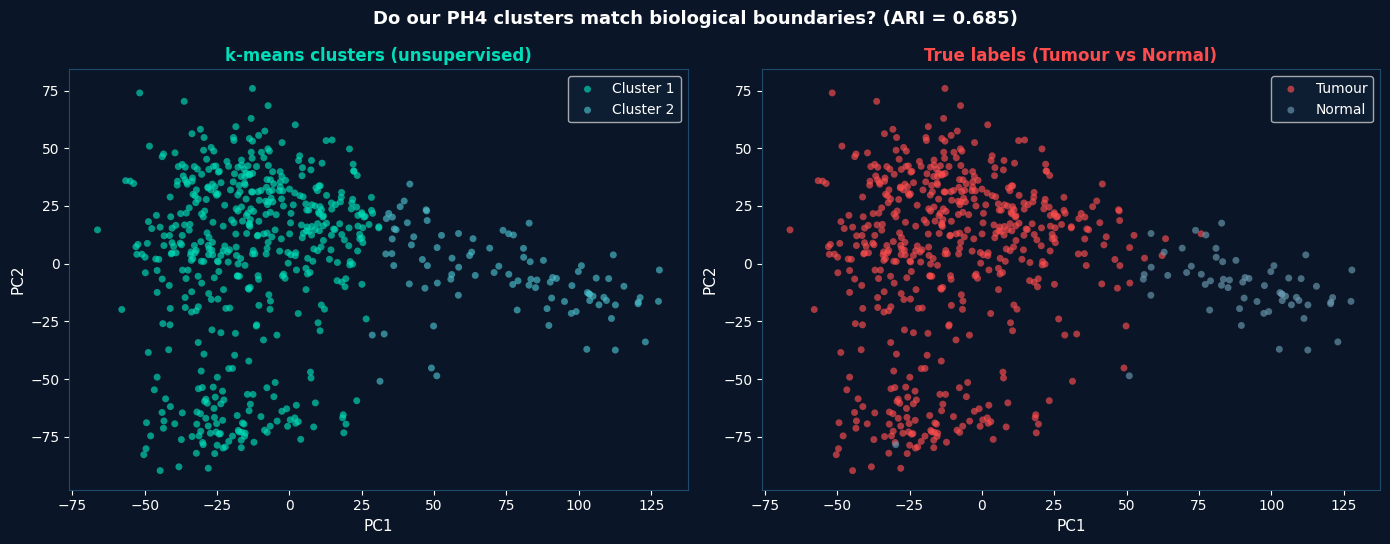

In [13]:
# K-means with k=2 on first 2 PCA components
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca_2d)

# Align clusters: ensure cluster label 1 corresponds to tumour majority
if y[cluster_labels == 1].mean() < 0.5:
    cluster_labels = 1 - cluster_labels

# Alignment score
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index (cluster vs true label): {ari:.4f}")
print(f"(1.0 = perfect, 0 = random - higher is better)\n")

# BRIDGE PLOT 
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#0A1628')

# Left: k-means clusters
for cluster_id, color, name in zip([1, 0], ['#00DDB8', '#4BBFCC'], ['Cluster 1', 'Cluster 2']):
    mask = cluster_labels == cluster_id
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=name, alpha=0.65, s=25, edgecolors='none')
axes[0].set_facecolor('#0A1628')
axes[0].set_xlabel('PC1', color='white', fontsize=11)
axes[0].set_ylabel('PC2', color='white', fontsize=11)
axes[0].set_title('k-means clusters (unsupervised)', color='#00DDB8',
                  fontweight='bold', fontsize=12)
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#0F2035', labelcolor='white', framealpha=0.8)
for spine in axes[0].spines.values():
    spine.set_color('#1E4A6B')

# Right: true labels
for label, color, name in zip([1, 0], ['#FF4D4D', '#6A9AB0'], ['Tumour', 'Normal']):
    mask = y == label
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=name, alpha=0.65, s=25, edgecolors='none')
axes[1].set_facecolor('#0A1628')
axes[1].set_xlabel('PC1', color='white', fontsize=11)
axes[1].set_ylabel('PC2', color='white', fontsize=11)
axes[1].set_title('True labels (Tumour vs Normal)', color='#FF4D4D',
                  fontweight='bold', fontsize=12)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#0F2035', labelcolor='white', framealpha=0.8)
for spine in axes[1].spines.values():
    spine.set_color('#1E4A6B')

plt.suptitle(f'Do our PH4 clusters match biological boundaries? (ARI = {ari:.3f})',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/bridge_visualization.png', dpi=150, bbox_inches='tight',
            facecolor='#0A1628')
plt.show()

## 6. Train / Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train - Tumour: {int(y_train.sum())}  Normal: {int((1-y_train).sum())}")
print(f"Test  - Tumour: {int(y_test.sum())}  Normal: {int((1-y_test).sum())}")

Train: 472 samples  |  Test: 118 samples
Train - Tumour: 423  Normal: 49
Test  - Tumour: 106  Normal: 12


## 7. Neural Network Architecture

In [17]:
input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,), name='gene_expression_input'),

    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu', name='hidden_3'),
    layers.Dropout(0.1),

    layers.Dense(1, activation='sigmoid', name='output')
], name='breast_cancer_MLP')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "breast_cancer_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Training

In [18]:
# Class weights to handle imbalance (529 tumour vs 61 normal)
n_total   = len(y_train)
n_tumour  = int(y_train.sum())
n_normal  = int((1 - y_train).sum())
class_weights = {0: n_total / (2 * n_normal),
                 1: n_total / (2 * n_tumour)}
print(f"Class weights: {class_weights}")

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Class weights: {0: 4.816326530612245, 1: 0.557919621749409}
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5889 - loss: 0.4719 - val_accuracy: 0.7158 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.2528 - val_accuracy: 0.7474 - val_loss: 0.7226 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9443 - loss: 0.1731 - val_accuracy: 0.8000 - val_loss: 0.5095 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9469 - loss: 0.1211 - val_accuracy: 0.8316 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9602 - loss: 0.0974 - val_accuracy: 0.8947 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9549 - loss: 0.0908 - val_accuracy: 0.9684 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━

## 9. Training Curves

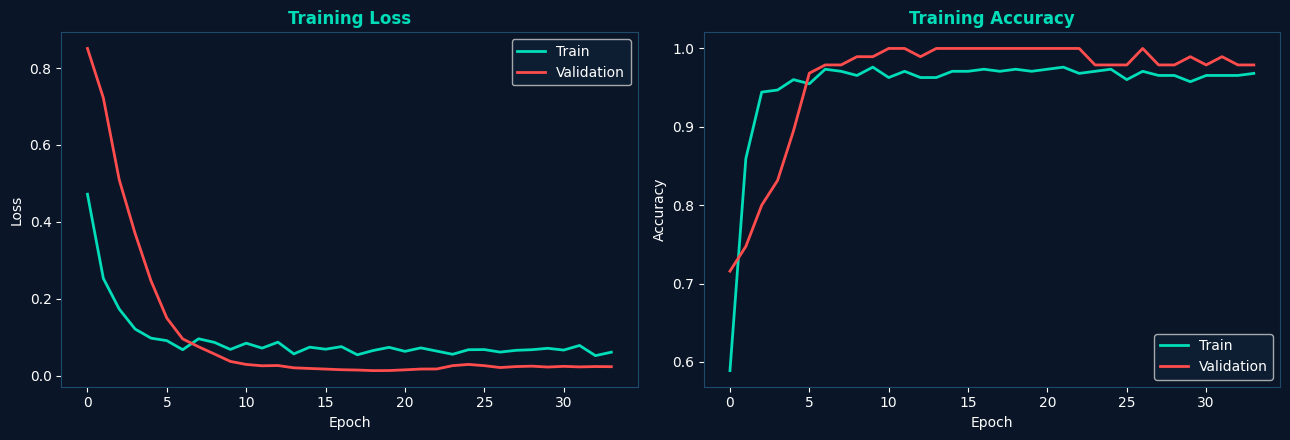

Best val loss at epoch: 19
Best val accuracy:      1.0000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0A1628')

for ax, metric, ylabel in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.set_facecolor('#0A1628')
    ax.plot(history.history[metric], color='#00DDB8', lw=2, label='Train')
    ax.plot(history.history[f'val_{metric}'], color='#FF4D4D', lw=2, label='Validation')
    ax.set_xlabel('Epoch', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_title(f'Training {ylabel}', color='#00DDB8', fontweight='bold')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#0F2035', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_color('#1E4A6B')

plt.tight_layout()
plt.savefig('../plots/nn_training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0A1628')
plt.show()

print(f"Best val loss at epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val accuracy:      {max(history.history['val_accuracy']):.4f}")

## 10. Evaluation on Test Set

In [20]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc    = accuracy_score(y_test, y_pred)
f1_w   = f1_score(y_test, y_pred, average='weighted')
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("=" * 55)
print("  NEURAL NETWORK RESULTS (held-out test set)")
print("=" * 55)
print(f"  Accuracy:     {acc*100:.2f}%")
print(f"  Weighted F1:  {f1_w:.4f}")
print(f"  AUC-ROC:      {roc_auc:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Tumour']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
  NEURAL NETWORK RESULTS (held-out test set)
  Accuracy:     97.46%
  Weighted F1:  0.9750
  AUC-ROC:      0.9332

              precision    recall  f1-score   support

      Normal       0.85      0.92      0.88        12
      Tumour       0.99      0.98      0.99       106

    accuracy                           0.97       118
   macro avg       0.92      0.95      0.93       118
weighted avg       0.98      0.97      0.98       118



## 11. Confusion Matrix + ROC Curve

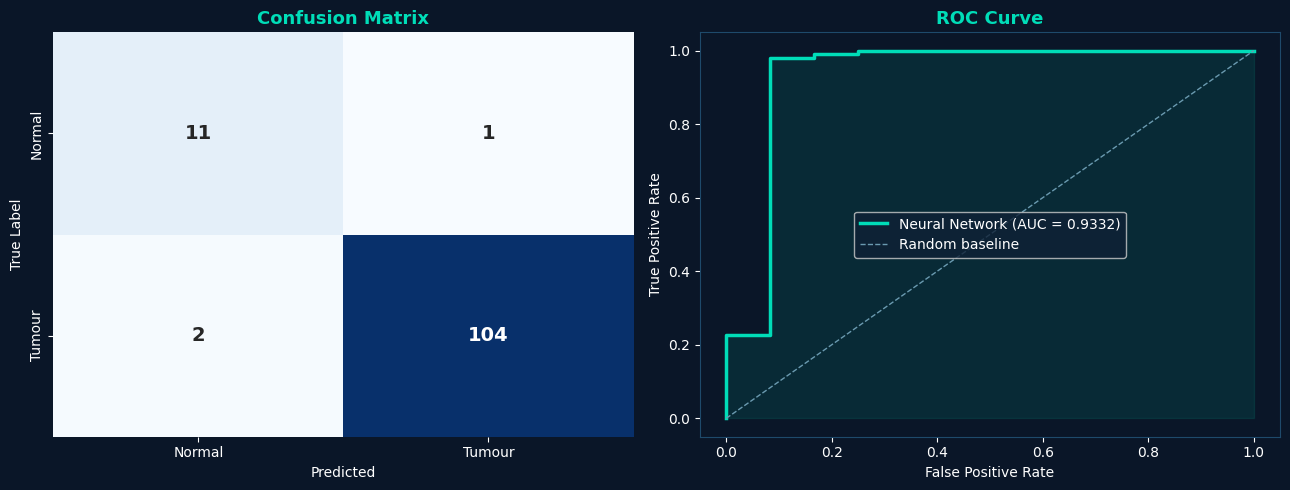

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0A1628')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Tumour'],
            yticklabels=['Normal', 'Tumour'], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_facecolor('#0A1628')
axes[0].set_title('Confusion Matrix', color='#00DDB8', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted', color='white')
axes[0].set_ylabel('True Label', color='white')
axes[0].tick_params(colors='white')

# ROC curve
axes[1].set_facecolor('#0A1628')
axes[1].plot(fpr, tpr, color='#00DDB8', lw=2.5, label=f'Neural Network (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#6A9AB0', linestyle='--', lw=1, label='Random baseline')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#00DDB8')
axes[1].set_xlabel('False Positive Rate', color='white')
axes[1].set_ylabel('True Positive Rate', color='white')
axes[1].set_title('ROC Curve', color='#00DDB8', fontweight='bold', fontsize=13)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#0F2035', labelcolor='white')
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('#1E4A6B')

plt.tight_layout()
plt.savefig('../plots/nn_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor='#0A1628')
plt.show()

## 12. Feature Importance (Top Genes)

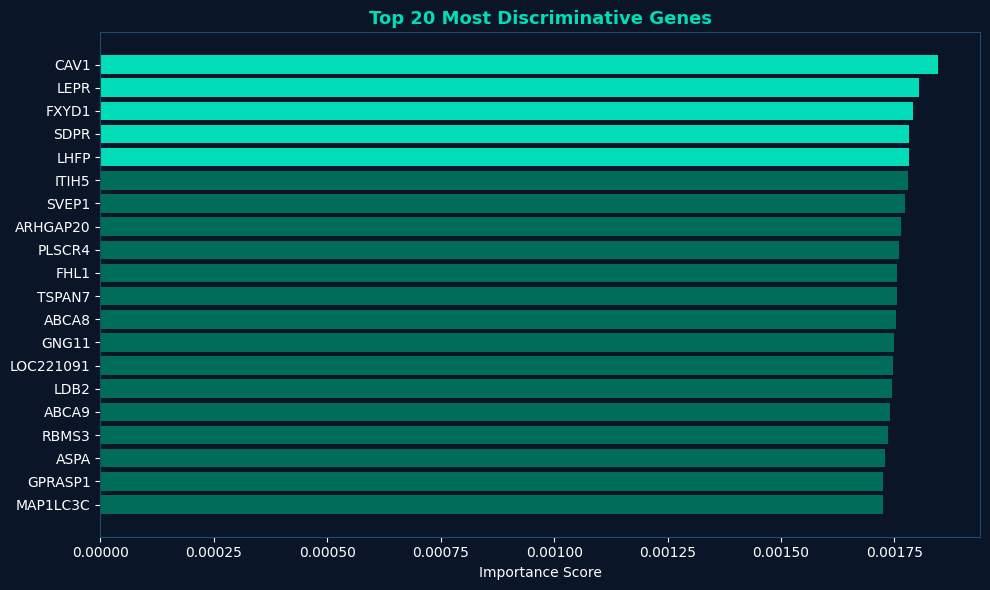

Top 10 most discriminative genes:
   1. CAV1             score: 0.001846
   2. LEPR             score: 0.001803
   3. FXYD1            score: 0.001792
   4. SDPR             score: 0.001782
   5. LHFP             score: 0.001781
   6. ITIH5            score: 0.001781
   7. SVEP1            score: 0.001773
   8. ARHGAP20         score: 0.001764
   9. PLSCR4           score: 0.001760
  10. FHL1             score: 0.001756


In [22]:
# Extract contribution of each gene via PCA loadings × first layer weights
# This gives us which original genes are most influential
first_layer_weights = np.abs(model.layers[0].get_weights()[0])  # shape: (n_pcs, 128)
pca_importance = first_layer_weights.mean(axis=1)  # average over 128 neurons

# Map back to gene space: gene_importance = sum(|PCA loading| * PC importance)
gene_loadings = np.abs(pca.components_)  # shape: (n_pcs, n_genes)
gene_importance = (gene_loadings * pca_importance[:, np.newaxis]).sum(axis=0)

# Get top 20 genes
top_idx = np.argsort(gene_importance)[::-1][:20]
top_genes = genes_kept[top_idx]
top_scores = gene_importance[top_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0A1628')
ax.set_facecolor('#0A1628')

colors_bar = ['#00DDB8' if i < 5 else '#006D5B' for i in range(20)]
bars = ax.barh(range(20), top_scores[::-1], color=colors_bar[::-1], edgecolor='none')
ax.set_yticks(range(20))
ax.set_yticklabels(top_genes[::-1], color='white', fontsize=10)
ax.set_xlabel('Importance Score', color='white')
ax.set_title('Top 20 Most Discriminative Genes', color='#00DDB8', fontweight='bold', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#1E4A6B')

plt.tight_layout()
plt.savefig('../plots/gene_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0A1628')
plt.show()

print("Top 10 most discriminative genes:")
for i, (gene, score) in enumerate(zip(top_genes[:10], top_scores[:10])):
    print(f"  {i+1:2d}. {gene:<15}  score: {score:.6f}")

## 13. Summary

In [23]:
print("=" * 60)
print("  FINAL SUMMARY of Ruman's Neural Network Notebook")
print("=" * 60)
print(f"  Dataset:       BC-TCGA ({int(y.sum())} tumour, {int((1-y).sum())} normal)")
print(f"  Features:      {X_scaled.shape[1]:,} genes → {n_90} PCA components")
print(f"  Architecture:  128 → 64 → 32 → 1 (sigmoid)")
print(f"  Epochs run:    {len(history.history['loss'])}")
print()
print(f"  TEST SET RESULTS:")
print(f"    Accuracy:    {acc*100:.2f}%")
print(f"    Weighted F1: {f1_w:.4f}")
print(f"    AUC-ROC:     {roc_auc:.4f}")
print()
print(f"  BRIDGE ANALYSIS:")
print(f"    Adjusted Rand Index: {ari:.4f}")
print(f"    (1.0 = perfect cluster-label alignment)")
print("=" * 60)
print()
print("Plots saved to ../plots/:")
print("  bridge_visualization.png")
print("  pca_variance.png")
print("  nn_training_curves.png")
print("  nn_evaluation.png")
print("  gene_importance.png")

  FINAL SUMMARY of Ruman's Neural Network Notebook
  Dataset:       BC-TCGA (529 tumour, 61 normal)
  Features:      17,488 genes → 1 PCA components
  Architecture:  128 → 64 → 32 → 1 (sigmoid)
  Epochs run:    34

  TEST SET RESULTS:
    Accuracy:    97.46%
    Weighted F1: 0.9750
    AUC-ROC:     0.9332

  BRIDGE ANALYSIS:
    Adjusted Rand Index: 0.6845
    (1.0 = perfect cluster-label alignment)

Plots saved to ../plots/:
  bridge_visualization.png
  pca_variance.png
  nn_training_curves.png
  nn_evaluation.png
  gene_importance.png
